In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import json

data_dir = Path("/home/bjoern/Projects/Masterarbeit/simdata/server/baseline")

filename_pattern = re.compile(
    r"base(\d+)agent(\d+)_(\d+)-(\d+)#(\d+)"
)

rows = []

for file in data_dir.iterdir():

    if file.suffix != ".json":
        continue

    match = filename_pattern.match(file.stem)

    if not match:
        print(f"Skipping {file.name}")
        continue

    experiment, agent, start, goal, run = map(int, match.groups())

    with open(file) as f:
        data = json.load(f)

    info = data["info"]

    row = {
        "experiment": experiment,
        "agent": agent,
        "start": start,
        "goal": goal,
        "run": run,
        "movement": f"{start}-{goal}",
        "converged": data["trajectory"] is not None,
        "NJS": info.get("NJS"),
        "EE_NJS": info.get("Endeffector_NJS"),
        "Solution_EE_NJS": info.get("Calculated_EE_NJS"),
        "Angle": info.get("Angle"),
        "av_dist_to_target": info.get("av_dist_to_target"),
        "Solution_EE_NJS_cropped" : info.get("EE_NJS_cropped"),
    }

    traj = data["trajectory"]

    if traj is not None:

        points = traj["points"]
        joints = traj["joint_names"]

        start_pos = points[0]["positions"]
        end_pos = points[-1]["positions"]

        for joint, s, e in zip(joints, start_pos, end_pos):
            row[f"{joint}_disp"] = e - s

        joint_vels = {j: [] for j in joints}
        joint_times = []  # shared time axis (same for all joints)

        for p in points:
            vels = p.get("velocities", [])

            # ---- extract time_from_start ----
            t = p.get("time_from_start", None)

            if t is not None:
                # handle ROS Duration-like dict
                sec = t.get("sec", 0)
                nsec = t.get("nanosec", 0)
                t_sec = sec + nsec * 1e-9
            else:
                t_sec = np.nan  # fallback if missing

            joint_times.append(t_sec)

            # ---- velocities ----
            for j, v in zip(joints, vels):
                joint_vels[j].append(v)

        # store velocities + time
        for j in joints:
            row[f"{j}_vel"] = joint_vels[j]

        # shared time vector for plotting v(t)
        row["trajectory_time"] = joint_times

    rows.append(row)

df = pd.DataFrame(rows)
print(df.head())

   experiment  agent  start  goal  run movement  converged           NJS  \
0          46      2      7     1    2      7-1       True  2.237922e+06   
1          37      2      7     9    1      7-9       True  4.941963e+06   
2          13      1      3     6    2      3-6       True  1.699652e+07   
3          39      2      7     1    2      7-1       True  1.858406e+06   
4          38      2      5     8    2      5-8       True  6.085110e+07   

       EE_NJS  Solution_EE_NJS  ...  \
0  106.194105     7.976347e+05  ...   
1   86.883654     9.339444e+05  ...   
2  161.275011     5.979027e+05  ...   
3  119.390008     6.931827e+05  ...   
4  421.636214     1.649406e+06  ...   

                              columna_flex_joint_vel  \
0  [0.0, 1.1301771080868388, 0.7498981581278721, ...   
1  [0.0, 1.1296515699534475, 0.7493545283112752, ...   
2  [0.0, 0.8632430951722695, 0.7007532845941888, ...   
3  [0.0, 1.1304948700669575, 0.7500989844990538, ...   
4  [0.0, 1.1079401908870221,

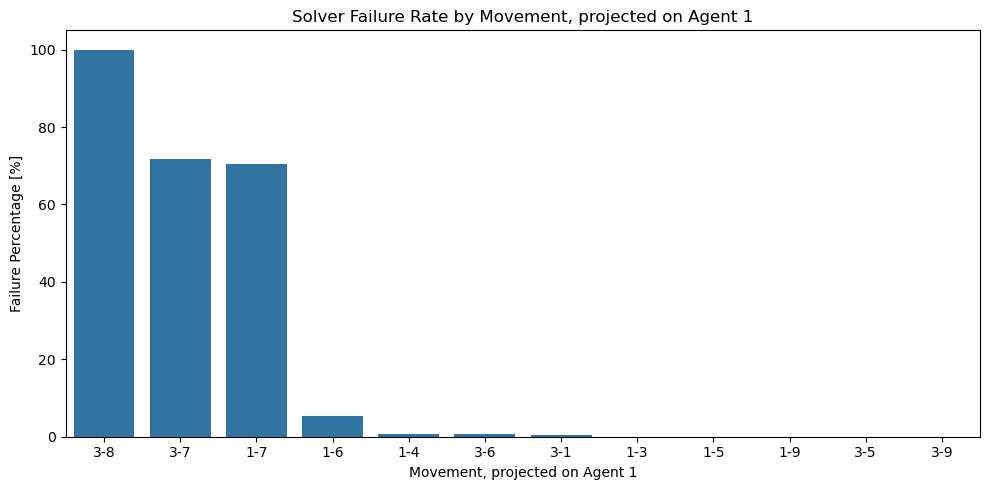

In [2]:
df["failure"] = ~df["converged"]

mirror = {
    1:5,
    2:6,
    3:7,
    4:8,
    5:1,
    6:2, 
    7:3,
    8:4,
    9:9,
}

def mirror_movement(start, goal):
    s = mirror[start]
    g = mirror[goal]
    return f"{s}-{g}"


df["projected_movement"] = np.where(
    df["agent"] == 1,
    df["movement"],
    df.apply(
        lambda r: mirror_movement(r["start"], r["goal"]),
        axis=1
    )
)

failure_rates = (
    df.groupby("projected_movement")["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
      .sort_values("failure_percent", ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=failure_rates,
    x="projected_movement",
    y="failure_percent"
)

plt.ylabel("Failure Percentage [%]")
plt.xlabel("Movement, projected on Agent 1")
plt.title("Solver Failure Rate by Movement, projected on Agent 1")

plt.tight_layout()
plt.show()

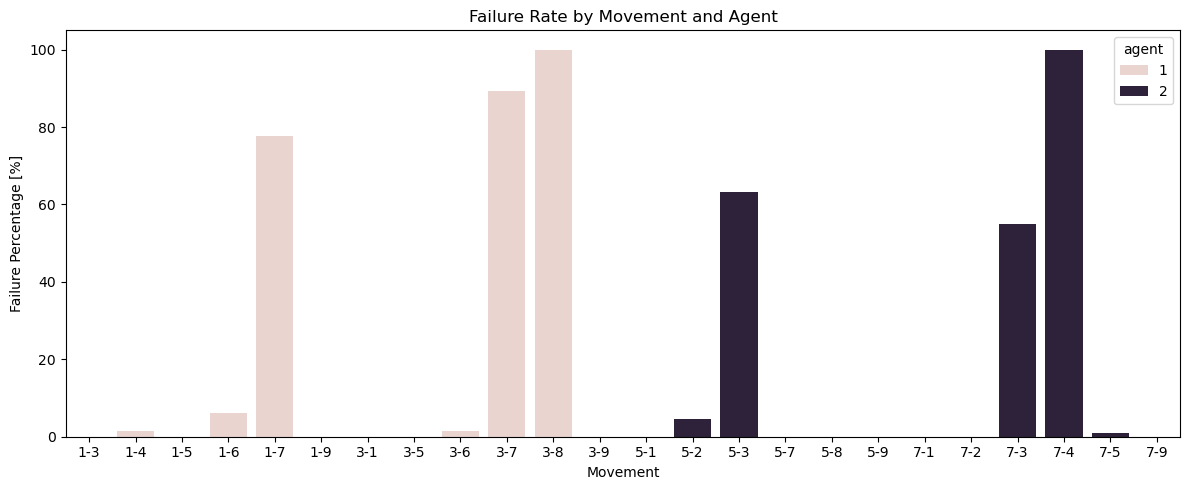

In [3]:
failure_rates = (
    df.groupby(["movement", "agent"])["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=failure_rates,
    x="movement",
    y="failure_percent",
    hue="agent"
)

plt.ylabel("Failure Percentage [%]")
plt.xlabel("Movement")
plt.title("Failure Rate by Movement and Agent")

plt.tight_layout()
plt.show()

In [4]:
print(df["agent"].value_counts())
print(df["agent"].value_counts())
print(df.groupby("agent")["movement"].unique())

agent
1    861
2    860
Name: count, dtype: int64
agent
1    861
2    860
Name: count, dtype: int64
agent
1    [3-6, 3-7, 3-5, 3-1, 1-3, 3-8, 1-6, 1-9, 3-9, ...
2    [7-1, 7-9, 5-8, 5-7, 7-5, 7-3, 7-2, 5-3, 5-2, ...
Name: movement, dtype: object


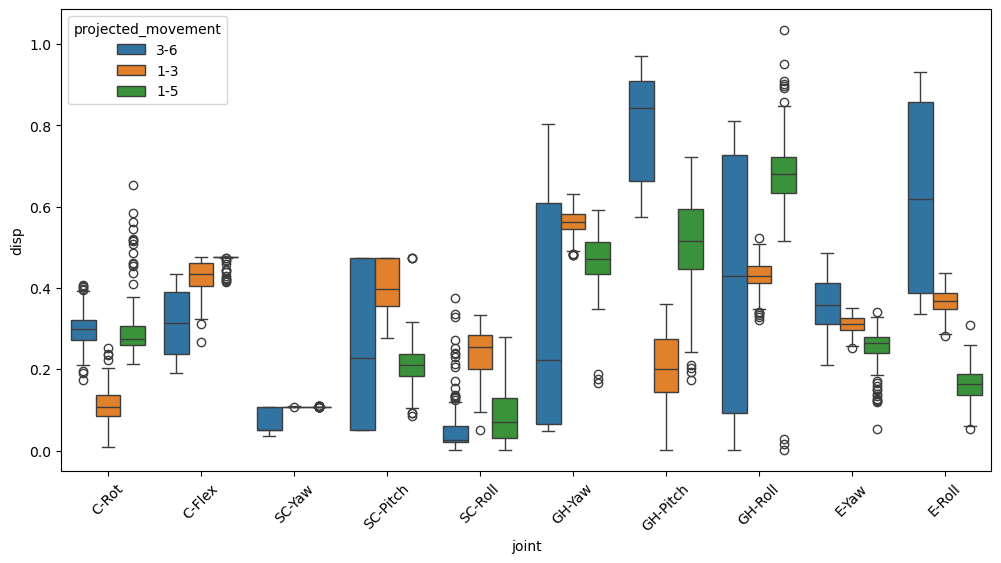

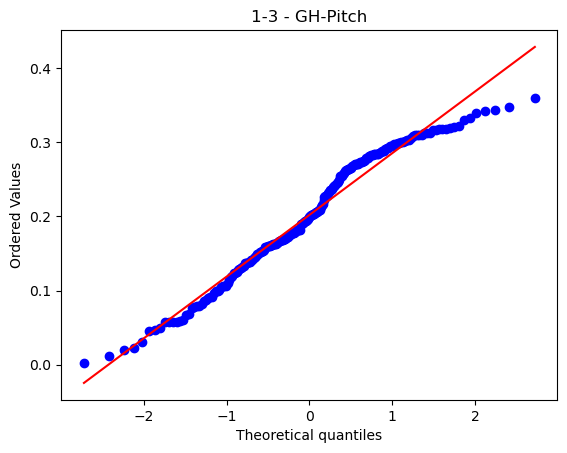

shapiro:  ShapiroResult(statistic=0.9687314629554749, pvalue=0.0001113648249884136)


In [5]:
joint_order = [
    "columna_rot_joint",
    "columna_flex_joint",
    "sternoclavicular_yaw_joint",
    "sternoclavicular_pitch_joint",
    "sternoclavicular_roll_joint",
    "glenohumeral_yaw_joint",
    "glenohumeral_pitch_joint",
    "glenohumeral_roll_joint",
    "elbow_yaw_joint",
    "elbow_roll_joint",
]

movements = ["1-3", "1-5", "3-6" ] #, "3-1"]

rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    for j in joint_order:
        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,
            "disp": abs(row[f"{j}_disp"])
        })

long_df = pd.DataFrame(rows)

joint_stats = long_df.groupby(["projected_movement", "joint"]).agg(
    mean=("disp", "mean"),
    std=("disp", "std")
).reset_index()

joint_labels = {
    "columna_rot_joint": "C-Rot",
    "columna_flex_joint": "C-Flex",
    "sternoclavicular_yaw_joint": "SC-Yaw",
    "sternoclavicular_pitch_joint": "SC-Pitch",
    "sternoclavicular_roll_joint": "SC-Roll",
    "glenohumeral_yaw_joint": "GH-Yaw",
    "glenohumeral_pitch_joint": "GH-Pitch",
    "glenohumeral_roll_joint": "GH-Roll",
    "elbow_yaw_joint": "E-Yaw",
    "elbow_roll_joint": "E-Roll",
}

joint_stats["joint"] = joint_stats["joint"].map(joint_labels)
long_df["joint"] = long_df["joint"].map(joint_labels)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=long_df,
    x="joint",
    y="disp",
    hue="projected_movement"
)

plt.xticks(rotation=45)
plt.show()

#Box plot?

movement = "1-3"
joint = "GH-Pitch"

x = long_df[
    (long_df.projected_movement == movement) &
    (long_df.joint == joint)
]["disp"]

from scipy.stats import probplot

probplot(x, dist="norm", plot=plt)
plt.title(f"{movement} - {joint}")
plt.show()

from scipy.stats import shapiro

print("shapiro: ", shapiro(x))

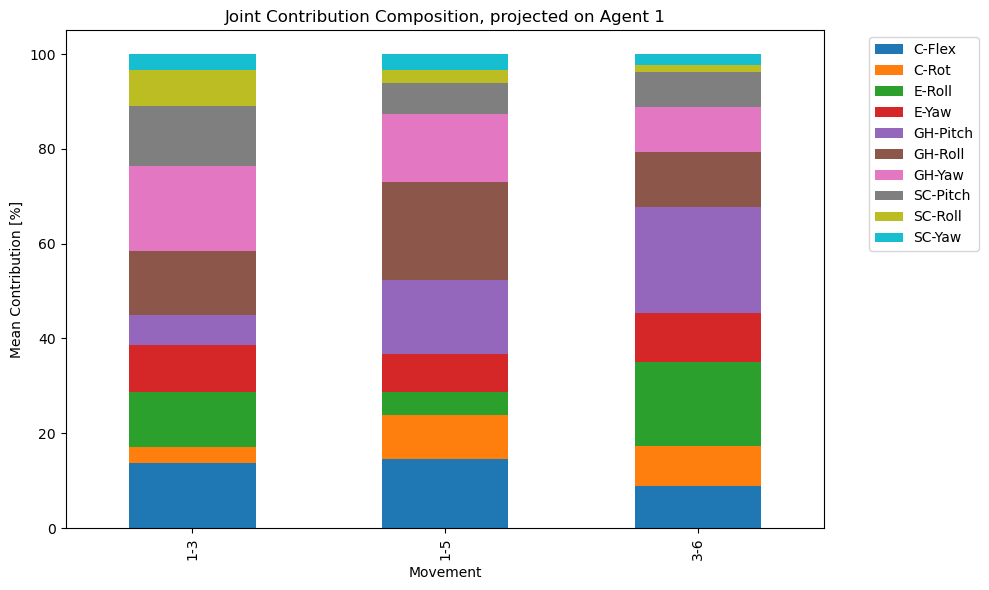

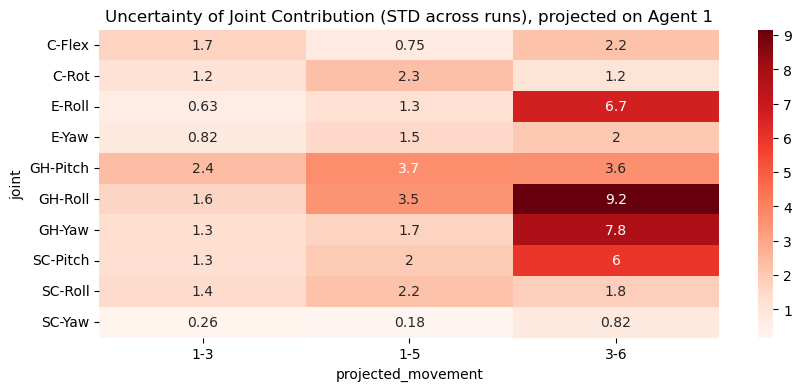

In [6]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):

        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

joint_stats = long_df.groupby(["projected_movement", "joint"]).agg(
    mean=("contribution", "mean"),
    std=("contribution", "std")
).reset_index()

joint_stats["joint"] = joint_stats["joint"].map(joint_labels)

pivot = joint_stats.pivot(
    index="projected_movement",
    columns="joint",
    values="mean"
)

ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.ylabel("Mean Contribution [%]")
plt.xlabel("Movement")
plt.title("Joint Contribution Composition, projected on Agent 1")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

err = joint_stats.pivot(
    columns="projected_movement",
    index="joint",
    values="std"
)

plt.figure(figsize=(10,4))

sns.heatmap(
    err,
    annot=True,
    cmap="Reds"
)

plt.title("Uncertainty of Joint Contribution (STD across runs), projected on Agent 1")
plt.show()

<Figure size 1200x600 with 0 Axes>

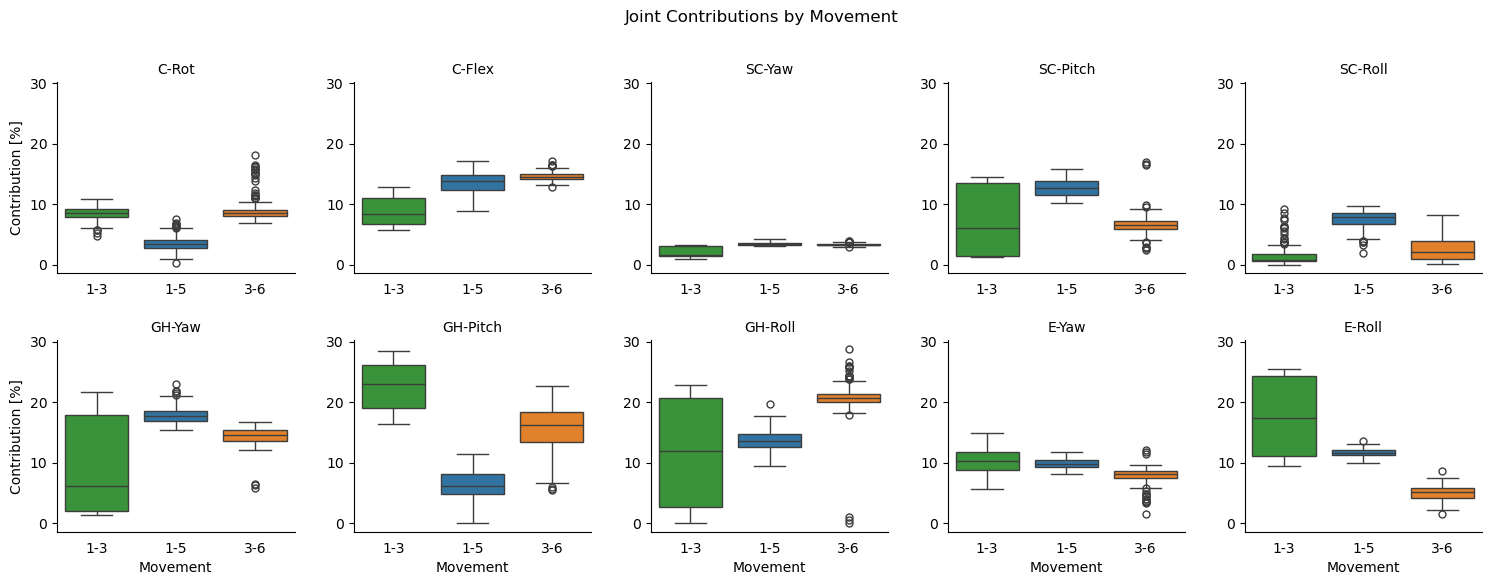

In [7]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):

        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

# map joint names for plotting
long_df["joint"] = long_df["joint"].map(joint_labels)

plt.figure(figsize=(12, 6))

palette = {
    "1-3": "#1f77b4",
    "1-5": "#ff7f0e",
    "3-6": "#2ca02c"
}
g = sns.catplot(
    data=long_df,
    x="projected_movement",
    y="contribution",
    col="joint",
    col_wrap=5,
    kind="box",
    hue="projected_movement",
    palette=palette,
    sharey=True,
    height=3,
    dodge=False,
    sharex=False
)

g.fig.subplots_adjust( 
    left=0.03, 
    right=0.98, 
    top=0.90, 
    bottom=0.15, 
    wspace=0.25, 
    hspace=0.35
)


g.set_xticklabels( movements, rotation=0,)
g.tick_params(bottom=False)
g.set_titles("{col_name}")
g.set_axis_labels("Movement", "Contribution [%]")
g.fig.suptitle("Joint Contributions by Movement", y=1.02)

for ax in g.axes.flat:
    ax.set_xlim(-0.5, 2.5)
    ax.margins(x=0.0)

for ax in g.axes.flat:
    ax.tick_params(axis="y", labelleft=True)

plt.show()

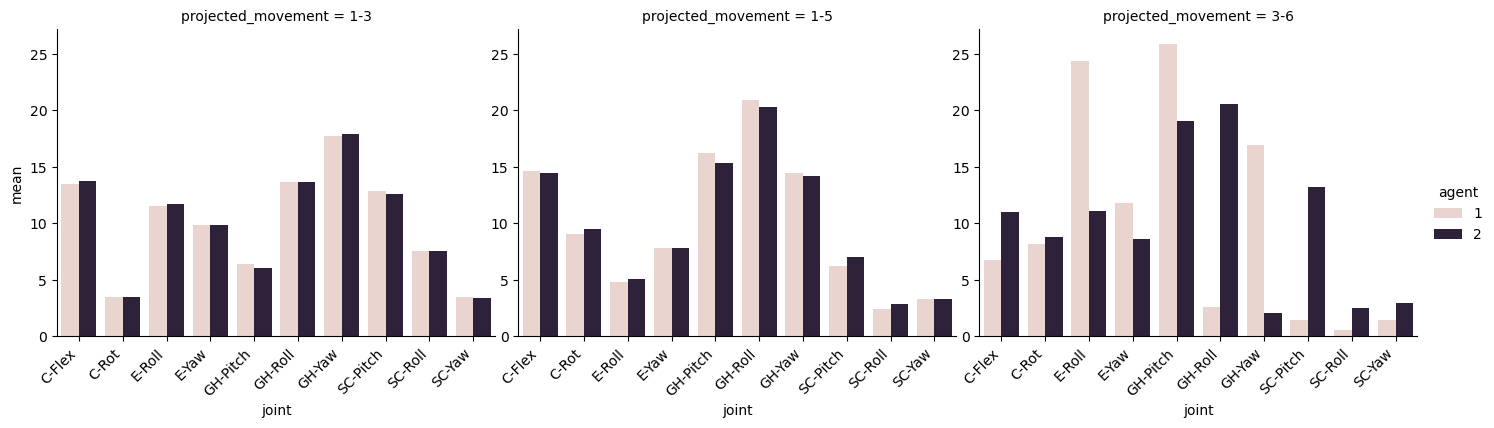

In [8]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):
        rows.append({
            "projected_movement": row["projected_movement"],
            "agent": row["agent"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

joint_stats = (
    long_df
    .groupby(["projected_movement", "agent", "joint"])
    .agg(
        mean=("contribution", "mean"),
        std=("contribution", "std")
    )
    .reset_index()
)

joint_stats["joint"] = joint_stats["joint"].map(joint_labels)


g = sns.catplot(
    data=joint_stats,
    kind="bar",
    x="joint",
    y="mean",
    hue="agent",
    col="projected_movement",
    col_wrap=3,
    height=4,
    aspect=1.2,
    errorbar=None,
    sharey=True
)

g.fig.subplots_adjust(hspace=0.3)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)
    
for ax in g.axes.flat:
    ax.tick_params(axis="y", labelleft=True)

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(),
             rotation=45,
             ha="right")
    


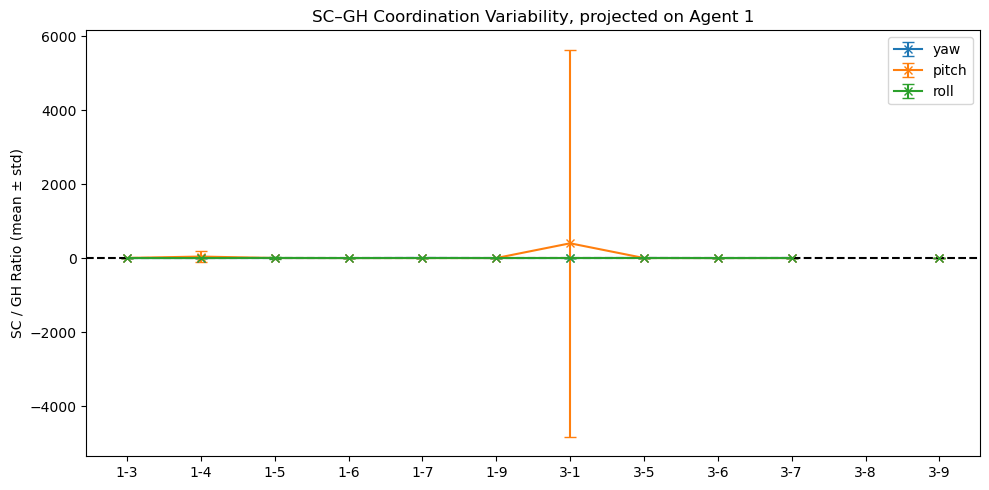

projected_movement  axis        SC/GH Ratio
               1-3   yaw      0.193 ± 0.011
               1-3 pitch      3.073 ± 8.058
               1-3  roll      0.571 ± 0.165
               1-4   yaw      0.174 ± 0.010
               1-4 pitch   40.215 ± 155.534
               1-4  roll      0.467 ± 0.136
               1-5   yaw      0.240 ± 0.063
               1-5 pitch      0.463 ± 0.254
               1-5  roll     3.212 ± 33.794
               1-6   yaw      0.472 ± 0.125
               1-6 pitch      0.238 ± 0.067
               1-6  roll      0.460 ± 0.184
               1-7   yaw      3.671 ± 0.731
               1-7 pitch      0.363 ± 0.108
               1-7  roll      0.589 ± 0.057
               1-9   yaw      0.716 ± 0.185
               1-9 pitch      0.266 ± 0.229
               1-9  roll      0.838 ± 0.663
               3-1   yaw      0.937 ± 0.784
               3-1 pitch 398.396 ± 5232.275
               3-1  roll      1.050 ± 4.490
               3-5   yaw      2.

In [9]:
sc_gh_pairs = [
    ("yaw",   "sternoclavicular_yaw_joint",   "glenohumeral_yaw_joint"),
    ("pitch", "sternoclavicular_pitch_joint", "glenohumeral_pitch_joint"),
    ("roll",  "sternoclavicular_roll_joint",  "glenohumeral_roll_joint"),
]

rows = []

for movement in sorted(df["projected_movement"].unique()):

    subset = df[
        (df["projected_movement"] == movement) &
        (df["converged"])
    ]

    for axis, sc, gh in sc_gh_pairs:

        sc_vals = subset[f"{sc}_disp"].abs()
        gh_vals = subset[f"{gh}_disp"].abs()

        ratio = sc_vals / gh_vals.replace(0, np.nan)
        #ratio = np.log((sc_vals + 1e-8) / (gh_vals + 1e-8))

        rows.append({
            "projected_movement": movement,
            "axis": axis,
            "mean": ratio.mean(),
            "std": ratio.std() 
        })

joint_stats = pd.DataFrame(rows)

plt.figure(figsize=(10,5))

for axis in joint_stats["axis"].unique():

    sub = joint_stats[joint_stats["axis"] == axis]

    plt.errorbar(
        sub["projected_movement"],
        sub["mean"],
        yerr= sub["std"],
        label=axis,
        capsize=4,
        marker="x"
    )

plt.axhline(0.5, linestyle="--", color="black")

plt.ylabel("SC / GH Ratio (mean ± std)")
plt.title("SC–GH Coordination Variability, projected on Agent 1")

#plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()


table = joint_stats.copy()

table["SC/GH Ratio"] = (
    table["mean"].map(lambda x: f"{x:.3f}")
    + " ± "
    + table["std"].map(lambda x: f"{x:.3f}")
)

table = table[["projected_movement", "axis", "SC/GH Ratio"]]

print(table.to_string(index=False))

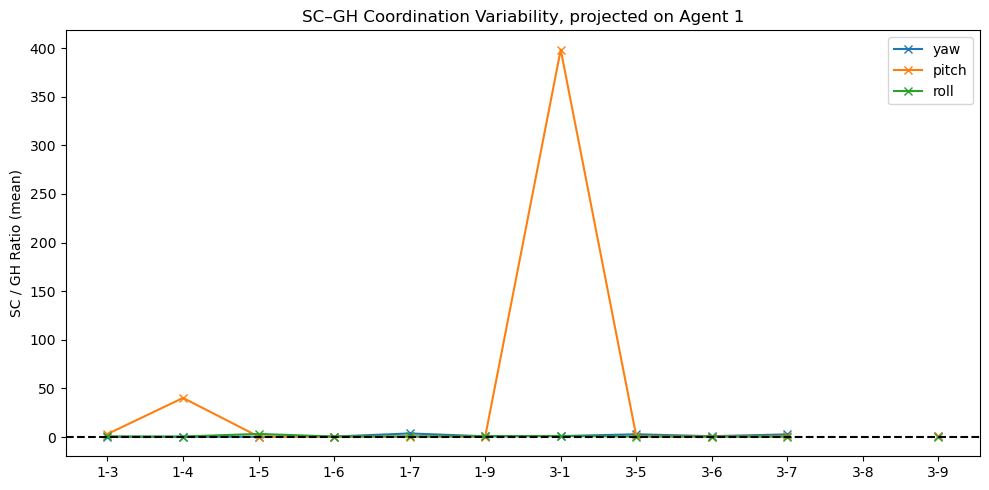

In [10]:
# same shit as before but without error bars:
plt.figure(figsize=(10,5))

# enforce consistent order
movement_order = sorted(joint_stats["projected_movement"].unique())

for axis in joint_stats["axis"].unique():

    sub = joint_stats[joint_stats["axis"] == axis]

    # force alignment with movement order
    sub = sub.set_index("projected_movement").reindex(movement_order).reset_index()

    plt.plot(
        sub["projected_movement"],
        sub["mean"],
        label=axis,
        marker="x"
    )

plt.axhline(0.5, linestyle="--", color="black")

plt.ylabel("SC / GH Ratio (mean)")
plt.title("SC–GH Coordination Variability, projected on Agent 1")

plt.legend()
plt.tight_layout()
plt.show()
#box plot, outlier raus 

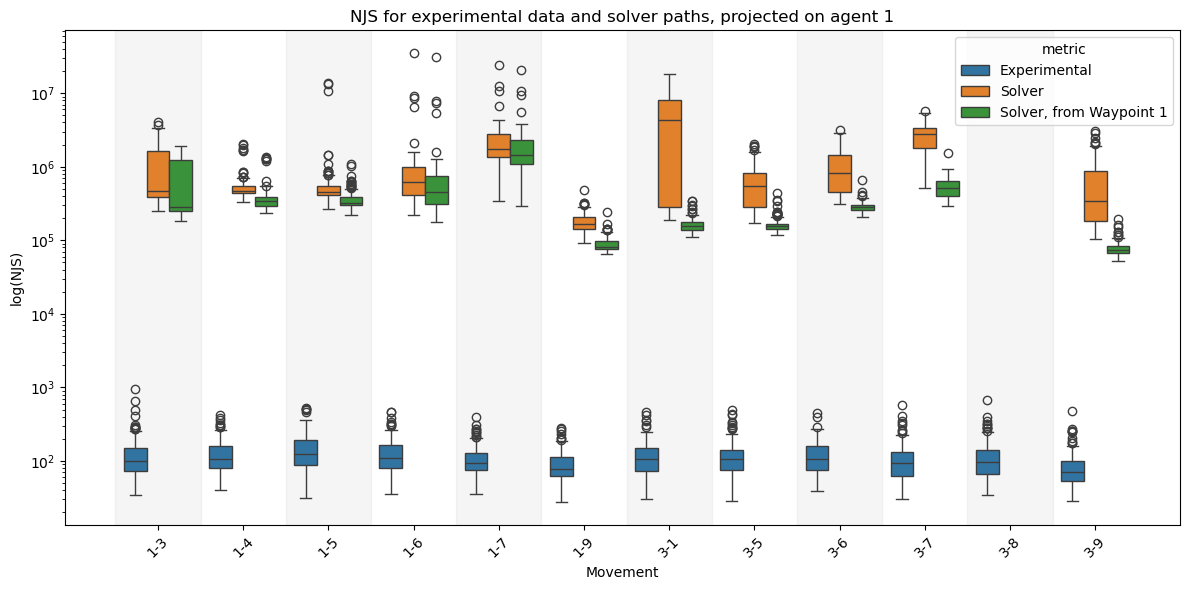

                   Solution_EE_NJS                                            \
                             count          mean        median           std   
projected_movement                                                             
1-3                            214  9.925041e+05  4.724224e+05  9.221018e+05   
1-4                            129  5.550477e+05  4.743478e+05  2.956184e+05   
1-5                            133  7.797986e+05  4.556987e+05  1.830910e+06   
1-6                            124  1.162286e+06  6.167493e+05  3.324429e+06   
1-7                             40  3.077576e+06  1.733119e+06  4.227022e+06   
1-9                            134  1.786449e+05  1.672597e+05  5.538990e+04   
3-1                            180  4.376001e+06  4.297503e+06  4.464800e+06   
3-5                            136  6.454228e+05  5.408922e+05  4.495237e+05   
3-6                            130  1.031711e+06  8.182108e+05  6.877726e+05   
3-7                             38  2.72

In [11]:
rows = []

for movement, group in df.groupby("projected_movement"):

    # EE_NJS (all runs)
    for v in group["EE_NJS"].dropna():
        rows.append({
            "projected_movement": movement,
            "metric": "EE_NJS",
            "value": v
        })

    # Solver (only converged)
    converged = group[group["converged"]]

    for v in converged["Solution_EE_NJS"].dropna():
        rows.append({
            "projected_movement": movement,
            "metric": "Solution_EE_NJS",
            "value": v
        })

    for v in converged["Solution_EE_NJS_cropped"].dropna():
        rows.append({
            "projected_movement": movement,
            "metric": "Solution_EE_NJS_cropped",
            "value": v
        })

metric_labels = {
    "EE_NJS": "Experimental",
    "Solution_EE_NJS": "Solver",
    "Solution_EE_NJS_cropped" : "Solver, from Waypoint 1"
}


long_df = pd.DataFrame(rows)
long_df["metric"] = long_df["metric"].map(metric_labels)

plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=long_df,
    x="projected_movement",
    y="value",
    hue="metric",
    showfliers=True
)

ax.set_yscale("log")

x_labels = sorted(long_df["projected_movement"].unique())
for i, m in enumerate(x_labels):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5, color="gray", alpha=0.08)

plt.ylabel("log(NJS)")
plt.xlabel("Movement")
plt.xticks(rotation=45)
plt.title("NJS for experimental data and solver paths, projected on agent 1")

plt.tight_layout()
plt.show()

summary = (
    df[df["converged"]]
    .groupby("projected_movement")
    [["Solution_EE_NJS", "Solution_EE_NJS_cropped"]]
    .agg(["count", "mean", "median", "std"])
)

print(summary)

df_conv = df[df["converged"]].dropna(subset=[
    "Solution_EE_NJS",
    "Solution_EE_NJS_cropped"
])

improvement = (df_conv["Solution_EE_NJS"] - df_conv["Solution_EE_NJS_cropped"]) / df_conv["Solution_EE_NJS"]

global_improvement_mean = 100 * improvement.mean()
gim_std = 100* improvement.std()
global_improvement_median = 100* improvement.median()
print("global improvement: mean:",global_improvement_mean, " pm ", gim_std ," median: ", global_improvement_median)

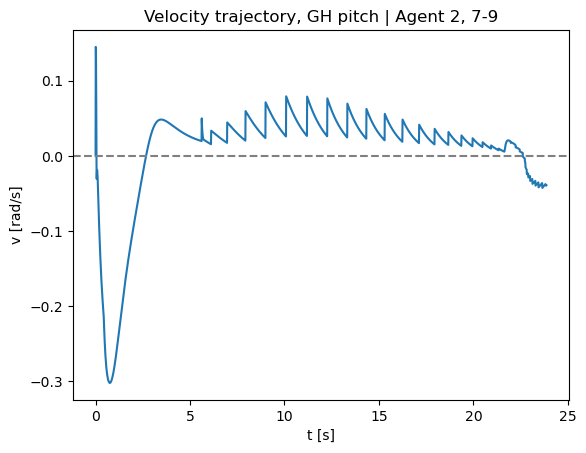

[(0.0, 0.0), (0.01, 0.14499454729721784), (0.02, 0.14192142590395407), (0.030000000000000002, 0.10620053097808466), (0.04, 0.051802739348316404), (0.05, -0.012204081203539024), (0.060000000000000005, -0.03068858499789139), (0.07, -0.021655549918592098), (0.08, -0.018875713745438467), (0.09000000000000001, -0.02015324922026411), (0.099999999, -0.02403213734297978), (0.109999999, -0.02954935950340311), (0.11999999900000001, -0.0381178657888785), (0.129999999, -0.046837530042209856), (0.14, -0.05532839401451041), (0.15000000000000002, -0.06359038144004774), (0.16, -0.07162390730620895), (0.17, -0.07942984239999423), (0.18000000000000002, -0.08700947781442003), (0.19, -0.09436448978728201), (0.2, -0.1014969051909345), (0.21000000000000002, -0.10840906794181232), (0.22, -0.11510360654915126), (0.23, -0.12158340297879339), (0.24000000000000002, -0.12785156296669092), (0.25, -0.13391138788027043), (0.26, -0.139766348193154), (0.27, -0.14542005861036197), (0.28, -0.15087625485627187), (0.29000

In [20]:
row = df.iloc[1]
mv = row["movement"]
ag = row["agent"]

t = row["trajectory_time"]
v = row["glenohumeral_pitch_joint_vel"]

t = np.array(t)
v = np.array(v)

mask = ~np.isnan(t)
t = t[mask]
v = v[mask]

plt.plot(t, v)

plt.title(f"Velocity trajectory, GH pitch | Agent {ag}, {mv}")
plt.axhline(0.0, linestyle="--", color="grey")

plt.xlabel("t [s]")
plt.ylabel("v [rad/s]")
plt.show()

print(list(zip(t, v)))

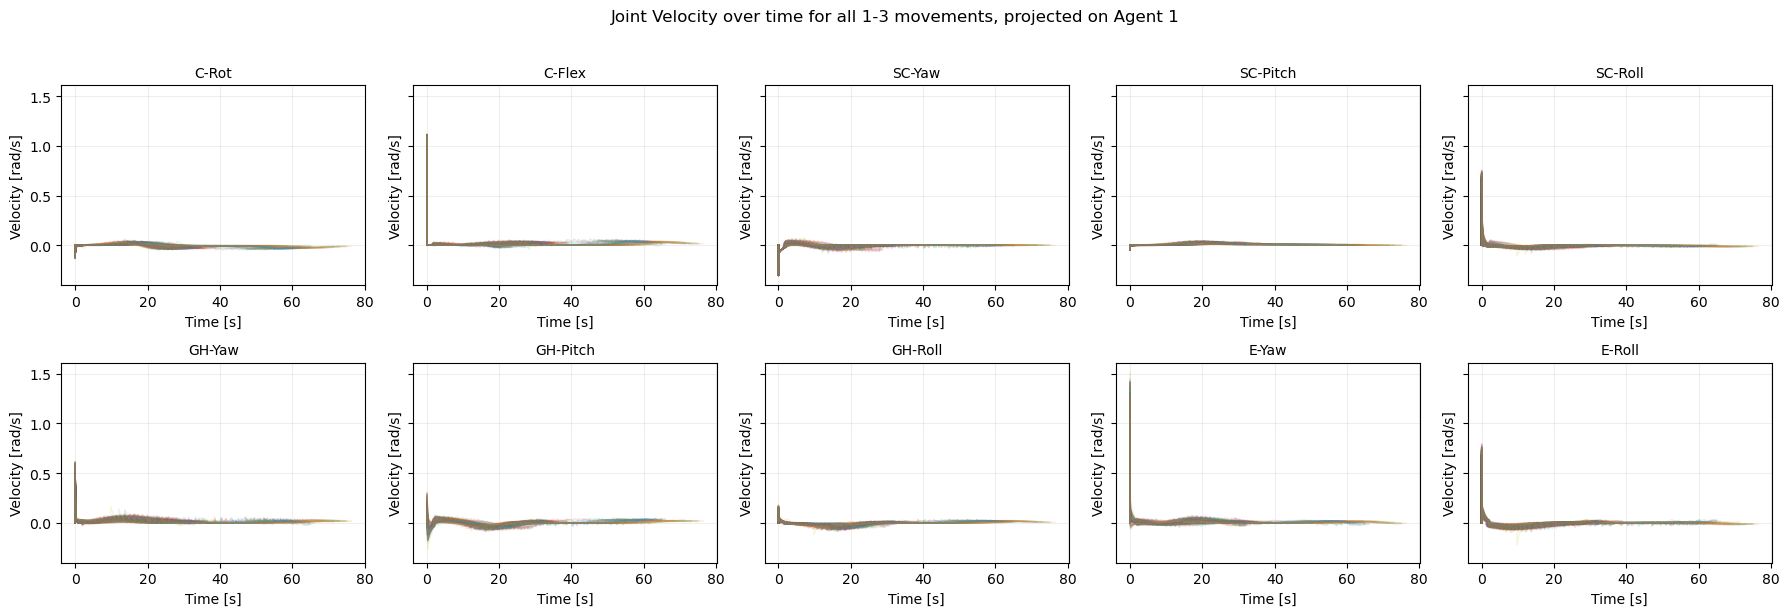

In [13]:

joint_list = joint_order

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(18, 6),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

for ax, joint in zip(axes, joint_list):

    vel_key = f"{joint}_vel"

    adj_movements = ["1-3"]

    for movement in adj_movements:

        subset = df[
            (df["converged"]) &
            (df["projected_movement"] == movement)
        ]

        if len(subset) == 0:
            continue

        for _, row in subset.iterrows():

            t = row.get("trajectory_time", None)
            v = row.get(vel_key, None)

            if t is None or v is None:
                continue

            t = np.asarray(t)
            v = np.asarray(v)

            if len(t) != len(v):
                continue

            mask = ~np.isnan(t)
            t = t[mask]
            v = v[mask]

            if len(t) < 2:
                continue

            ax.plot(
                t,
                v,
                alpha=0.15,
                linewidth=1,
                label=movement
            )

    ax.set_title(joint_labels.get(joint, joint), fontsize=10)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Velocity [rad/s]")
    ax.grid(True, alpha=0.2)

fig.suptitle("Joint Velocity over time for all 1-3 movements, projected on Agent 1", y=1.02)
plt.tight_layout()
plt.show()

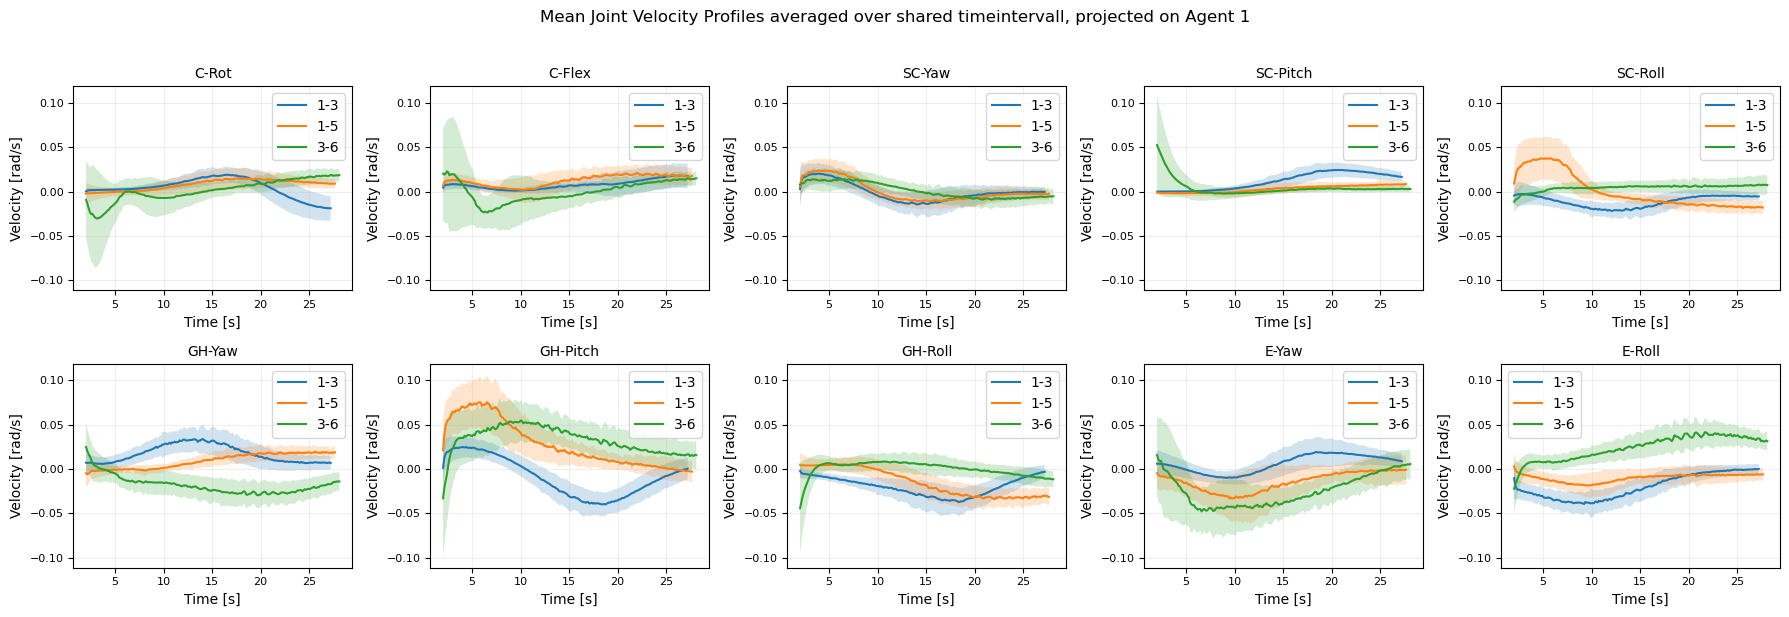

In [14]:
from scipy.interpolate import interp1d

joint_list = joint_order

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(18, 6),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, joint in zip(axes, joint_list):

    vel_key = f"{joint}_vel"

    for movement in movements:

        subset = df[
            (df["converged"]) &
            (df["projected_movement"] == movement)
        ]

        if len(subset) == 0:
            continue

        # ------------------------------------------------------------
        # 1. collect all (t, v) pairs
        # ------------------------------------------------------------
        NOISE_CUTOFF = 200*0.01  # 200 ms

        traj_data = []

        for _, row in subset.iterrows():

            t = row.get("trajectory_time", None)
            v = row.get(vel_key, None)

            if t is None or v is None:
                continue

            t = np.array(t)
            v = np.array(v)

            mask = ~np.isnan(t)
            t = t[mask]
            v = v[mask]

            if len(t) < 2:
                continue

            # ------------------------------------------------------------
            # remove initial noisy phase (IMPORTANT)
            # ------------------------------------------------------------
            t0 = t[0]
            valid = t >= (t0 + NOISE_CUTOFF)

            t = t[valid]
            v = v[valid]

            if len(t) < 2:
                continue

            traj_data.append((t, v))

            if len(traj_data) == 0:
                continue

        # ------------------------------------------------------------
        # 2. compute common overlapping time window
        # ------------------------------------------------------------
        t_start = max(t[0] for t, _ in traj_data)
        t_end   = min(t[-1] for t, _ in traj_data)

        if t_end <= t_start:
            continue

        common_t = np.linspace(t_start, t_end, 200)

        # ------------------------------------------------------------
        # 3. interpolate all trajectories onto common time base
        # ------------------------------------------------------------
        aligned = []

        for t, v in traj_data:

            f = interp1d(
                t,
                v,
                kind="linear",
                bounds_error=False,
                fill_value="extrapolate"
            )

            aligned.append(f(common_t))

        aligned = np.array(aligned)

        # ------------------------------------------------------------
        # 4. statistics
        # ------------------------------------------------------------
        mean_traj = aligned.mean(axis=0)
        std_traj  = aligned.std(axis=0)

        # ------------------------------------------------------------
        # 5. plot
        # ------------------------------------------------------------
        ax.plot(common_t, mean_traj, label=movement)

        ax.fill_between(
            common_t,
            mean_traj - std_traj,
            mean_traj + std_traj,
            alpha=0.2
        )

    ax.set_title(joint_labels.get(joint, joint), fontsize=10)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Velocity [rad/s]")
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis="both", labelsize=8)
    ax.legend()

for ax in axes.flat:
    ax.tick_params(axis="x", labelbottom=True)
    ax.tick_params(axis="y", labelleft=True)

fig.suptitle("Mean Joint Velocity Profiles averaged over shared timeintervall, projected on Agent 1", y=1.02)
plt.tight_layout()
plt.show()

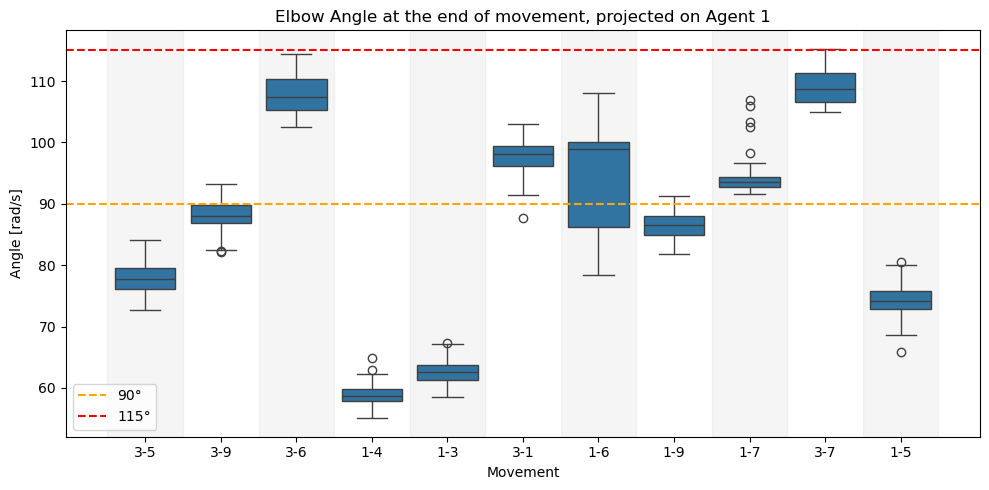

55.05091290194858


In [15]:
subset = df[df["converged"]]

plt.figure(figsize=(10, 5))

ax = sns.boxplot(
    data=subset,
    x="projected_movement",
    y="Angle",
    showfliers=True
)

for i in range(len(sorted(subset["projected_movement"].unique()))):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5,
                   color="gray", alpha=0.08, zorder=0)

ax.axhline(
    y=90,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="90°"
)

ax.axhline(
    y=115,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="115°"
)


ax.legend()
ax.set_ylabel("Angle [rad/s]")
ax.set_xlabel("Movement")


plt.title("Elbow Angle at the end of movement, projected on Agent 1")
plt.tight_layout()
plt.show()
print(min(subset["Angle"]))

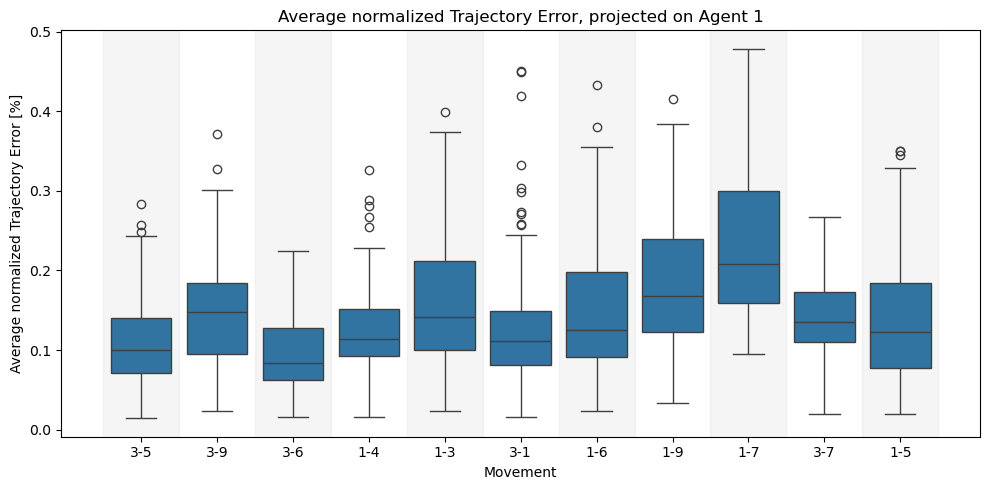

In [16]:
subset = df[df["converged"]].copy()

subset["av_dist_to_target_pct"] = subset["av_dist_to_target"] * 100
plt.figure(figsize=(10, 5))

ax = sns.boxplot(
    data=subset,
    x="projected_movement",
    y="av_dist_to_target_pct",
    showfliers=True
)

for i in range(len(sorted(subset["projected_movement"].unique()))):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5,
                   color="gray", alpha=0.08, zorder=0)


ax.set_ylabel("Average normalized Trajectory Error [%]")
ax.set_xlabel("Movement")


plt.title("Average normalized Trajectory Error, projected on Agent 1")
plt.tight_layout()
plt.show()